In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data/processed/clean_data.csv",
    parse_dates=["system_time"]
)

df.set_index("system_time", inplace=True)
df.head()

,Unnamed: 0,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,bids_distance_4,...,asks_market_notional_5,asks_market_notional_6,asks_market_notional_7,asks_market_notional_8,asks_market_notional_9,asks_market_notional_10,asks_market_notional_11,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14
system_time,,,,,,,,,,,,,,,,,,,,,
2021-04-07 11:33:41.122161+00:00,0,55896.285,0.01,4.448599e+06,3.899402e+06,-8.945138e-08,-0.000065,-0.000073,-0.000154,-0.000162,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1176.72998,0.0
2021-04-07 11:34:41.122161+00:00,1,55948.685,1.43,1.243244e+06,3.606502e+06,-1.277957e-05,-0.000013,-0.000242,-0.000242,-0.000259,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2021-04-07 11:35:41.122161+00:00,2,56013.785,0.01,3.069094e+06,1.575759e+06,-8.926374e-08,-0.000009,-0.000070,-0.000088,-0.000173,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2021-04-07 11:36:41.122161+00:00,3,55903.575,7.17,1.220819e+06,1.321487e+06,-6.412827e-05,-0.000182,-0.000188,-0.000225,-0.000310,...,0.0,312.040009,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2021-04-07 11:37:41.122161+00:00,4,55899.995,0.01,2.011287e+06,3.083005e+06,-8.944544e-08,-0.000129,-0.000130,-0.000143,-0.000201,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0


In [2]:
import numpy as np

df["log_return"] = np.log(df["midpoint"]).diff()
df["log_return"].head()

C:\Users\jinda\AppData\Local\Temp\ipykernel_13320\911010614.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["log_return"] = np.log(df["midpoint"]).diff()


system_time
2021-04-07 11:33:41.122161+00:00         NaN
2021-04-07 11:34:41.122161+00:00    0.000937
2021-04-07 11:35:41.122161+00:00    0.001163
2021-04-07 11:36:41.122161+00:00   -0.001969
2021-04-07 11:37:41.122161+00:00   -0.000064
Name: log_return, dtype: float64

In [5]:
df = df.copy()

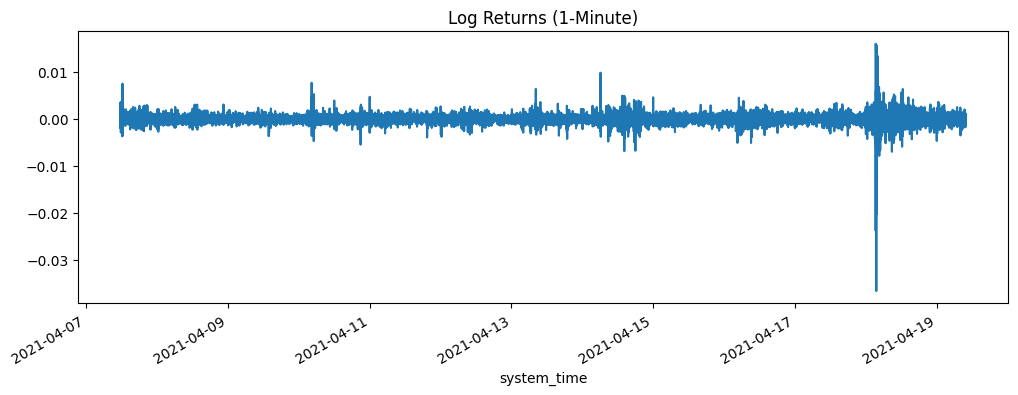

In [4]:
df["log_return"].plot(figsize=(12,4))
plt.title("Log Returns (1-Minute)")
plt.show()

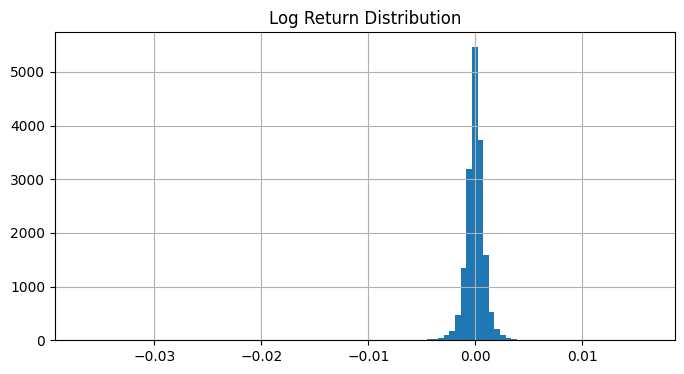

In [6]:
df["log_return"].hist(bins=100, figsize=(8,4))
plt.title("Log Return Distribution")
plt.show()


In [8]:
from scipy.stats import skew, kurtosis

print("Mean:", df["log_return"].mean())
print("Std:", df["log_return"].std())
print("Skewness:", skew(df["log_return"].dropna()))
print("Kurtosis:", kurtosis(df["log_return"].dropna()))

Mean: 1.0017287414321215e-06
Std: 0.0010669772548053953
Skewness: -3.028107750793248
Kurtosis: 133.66074875989386


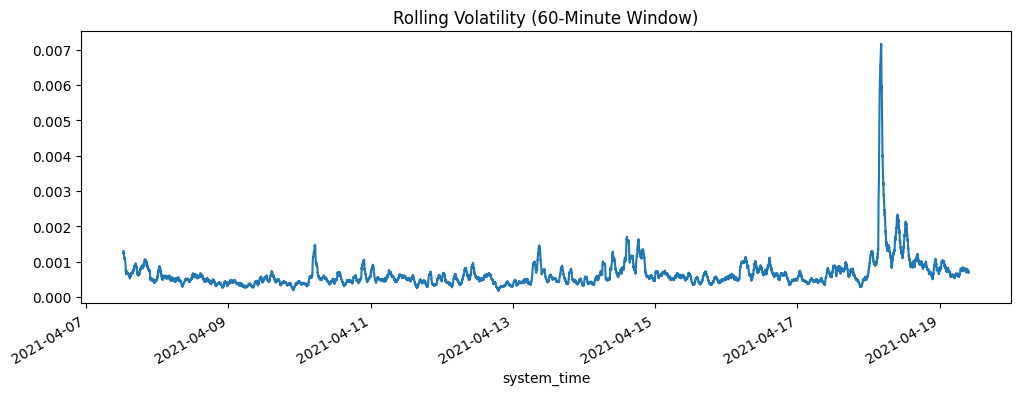

In [9]:
df["abs_return"] = df["log_return"].abs()
df["rolling_vol"] = df["abs_return"].rolling(60).mean()

df["rolling_vol"].plot(figsize=(12,4))
plt.title("Rolling Volatility (60-Minute Window)")
plt.show()

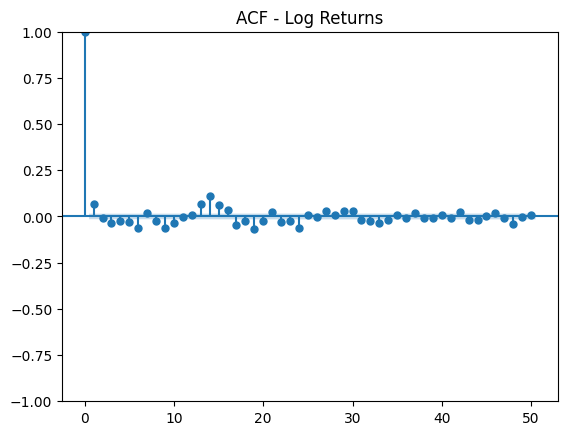

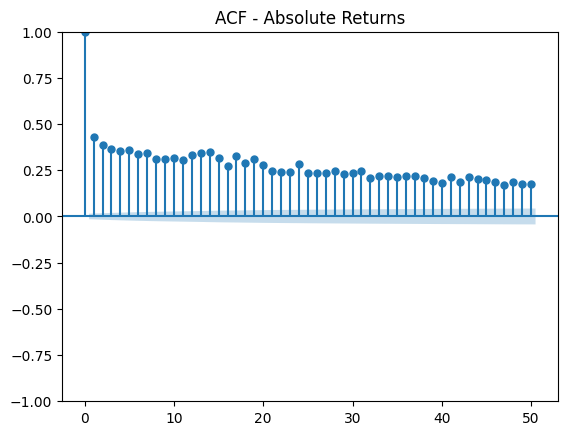

In [10]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["log_return"].dropna(), lags=50)
plt.title("ACF - Log Returns")
plt.show()

plot_acf(df["abs_return"].dropna(), lags=50)
plt.title("ACF - Absolute Returns")
plt.show()

In [11]:
df[["spread", "rolling_vol"]].corr()

,spread,rolling_vol
spread,1.000000,0.404643
rolling_vol,0.404643,1.000000


In [1]:
plt.figure(figsize=(8,5))

plt.scatter(df["trade_intensity"], df["spread"], alpha=0.3)

plt.title("Spread vs Trade Intensity")
plt.xlabel("Trade Intensity")
plt.ylabel("Bid-Ask Spread")

plt.savefig("../reports/figures/spread_vs_trade_intensity.png", dpi=300)

plt.show()

NameError: name 'plt' is not defined

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["trade_intensity"], df["spread"], alpha=0.3)

plt.title("Spread vs Trade Intensity")
plt.xlabel("Trade Intensity")
plt.ylabel("Bid-Ask Spread")

plt.savefig("../reports/figures/spread_vs_trade_intensity.png", dpi=300)

plt.show()

NameError: name 'df' is not defined

<Figure size 800x500 with 0 Axes>

In [4]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_data.csv")

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("../data/processed/clean_data.csv")

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(df["trade_intensity"], df["spread"], alpha=0.3)

plt.title("Spread vs Trade Intensity")
plt.xlabel("Trade Intensity")
plt.ylabel("Bid-Ask Spread")

plt.savefig("../reports/figures/spread_vs_trade_intensity.png", dpi=300)

plt.show()

KeyError: 'trade_intensity'

<Figure size 800x500 with 0 Axes>

In [8]:
df["trade_intensity"] = df["volume"].rolling(50).sum()

KeyError: 'volume'

In [9]:
df.columns

Index(['Unnamed: 0', 'system_time', 'midpoint', 'spread', 'buys', 'sells',
       'bids_distance_0', 'bids_distance_1', 'bids_distance_2',
       'bids_distance_3',
       ...
       'asks_market_notional_5', 'asks_market_notional_6',
       'asks_market_notional_7', 'asks_market_notional_8',
       'asks_market_notional_9', 'asks_market_notional_10',
       'asks_market_notional_11', 'asks_market_notional_12',
       'asks_market_notional_13', 'asks_market_notional_14'],
      dtype='str', length=156)

In [10]:
df["trade_intensity"] = df.index.to_series().rolling(50).count()

C:\Users\jinda\AppData\Local\Temp\ipykernel_10676\3973767133.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["trade_intensity"] = df.index.to_series().rolling(50).count()


In [11]:
df[["trade_intensity","spread"]].head()

,trade_intensity,spread
0,NaN,0.01
1,NaN,1.43
2,NaN,0.01
3,NaN,7.17
4,NaN,0.01


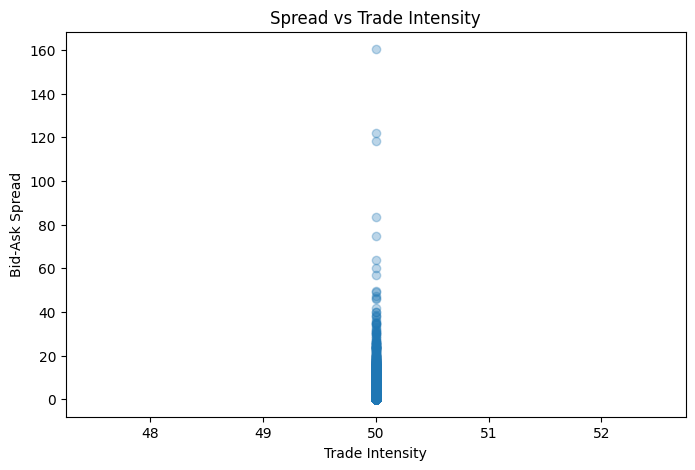

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["trade_intensity"], df["spread"], alpha=0.3)

plt.title("Spread vs Trade Intensity")
plt.xlabel("Trade Intensity")
plt.ylabel("Bid-Ask Spread")

plt.savefig("../reports/figures/spread_vs_trade_intensity.png", dpi=300)

plt.show()